In [252]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from tqdm.auto import tqdm
import re

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

## Reading Dataset

In [253]:
dataset_path = os.path.join('..', 'datasets', 'archive')

comments = pd.read_csv(
    os.path.join(dataset_path, 'UScomments.csv'),
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False
)
videos = pd.read_csv(
    os.path.join(dataset_path, 'USvideos.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

In [254]:
display(comments.head()) # Display the first few rows of the dataset
display(comments.info()) # Display the information about the dataset

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


None

In [255]:
comments.loc[comments['comment_text'].isna()]  # Filter rows based on condition

,video_id,comment_text,likes,replies
1417,1L7JFN7tQLs,NaN,0,0
76134,7YAAyUFL1GQ,NaN,0,0
215218,KUCHBBCj77I,NaN,0,0
234226,KUCHBBCj77I,NaN,0,0
306019,s3Hk_lDw5yo,NaN,0,0
332811,zrOHeEA14kQ,NaN,0,0
357506,zmg9tVaMVd4,NaN,0,0
379582,zmg9tVaMVd4,NaN,0,0
403013,9eea7_7OBZQ,NaN,0,0
425238,6l5P7jHUcjI,NaN,0,0


In [256]:
comments.dropna(inplace=True) # Drop rows with null values

In [257]:
comments.info() # Check the data types and null values

<class 'pandas.core.frame.DataFrame'>
Index: 691374 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691374 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691374 non-null  object
 3   replies       691374 non-null  object
dtypes: object(4)
memory usage: 26.4+ MB


## Splitting into Training and Test Set

In [258]:
# Split the dataset
train_comments, test_comments = train_test_split(comments, test_size=0.2, random_state=42)
comments_dummy = comments.copy() # Create a copy of the comments DataFrame to use for dummy model (TextBlob)

## Text Cleaning & Tokenization

In [259]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [260]:
def clear_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"(@\S+|#\S+|http\S+|[^a-zA-Z\s])", " ", text)  # Combine regex patterns to remove mentions, hashtags, URLs, and special characters
    text = re.sub(r"\s+", " ", text).strip()  # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

In [261]:
train_comments['comment_text'] = train_comments['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
test_comments['comment_text'] = test_comments['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
comments_dummy['comment_text'] = comments_dummy['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)

## Stop Word Removal/Lemmatization

In [262]:
stop_words = set(stopwords.words('english')) # Set of English stop words
lemmatizer = WordNetLemmatizer() # Initialize the lemmatizer

# Remove stop words and apply lemmatization to the tokenized text
train_comments['tokenized_text'] = train_comments['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
train_comments['tokenized_text'] = train_comments['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

test_comments['tokenized_text'] = test_comments['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
test_comments['tokenized_text'] = test_comments['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

comments_dummy['tokenized_text'] = comments_dummy['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
comments_dummy['tokenized_text'] = comments_dummy['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

In [263]:
train_comments['tokenized_text'] = train_comments['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
test_comments['tokenized_text'] = test_comments['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
comments_dummy['tokenized_text'] = comments_dummy['tokenized_text'].apply(lambda tokens: ' '.join(tokens))

## Creating Like-to-Dislike Ratio

In [264]:
total_interactions = videos['likes'] + videos['dislikes'] # Calculate total interactions
videos['l_d_ratio'] = videos['likes'] / total_interactions # Calculate the like-dislike ratio
videos.head(10)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,l_d_ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09,0.981806
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,13.09,0.874471
2,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09,0.935471
3,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09,0.846123
4,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09,0.994158
5,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,A24,1,a24|a24 films|a24 trailers|independent films|t...,1311445,34507,544,3040,https://i.ytimg.com/vi/cMKX2tE5Luk/default.jpg,13.09,0.984480
6,8wNr-NQImFg,"The Check In: HUD, Ben Carson and Hurricanes",Late Night with Seth Meyers,23,Late night|Seth Meyers|check in|hud|Ben Carson...,666169,9985,297,1071,https://i.ytimg.com/vi/8wNr-NQImFg/default.jpg,13.09,0.971115
7,_HTXMhKWqnA,iPhone X Impressions & Hands On!,Marques Brownlee,28,iPhone X|iphone x|iphone 10|iPhone X impressio...,1728614,74062,2180,15297,https://i.ytimg.com/vi/_HTXMhKWqnA/default.jpg,13.09,0.971407
8,_ANP3HR1jsM,ATTACKED BY A POLICE DOG!!,RomanAtwoodVlogs,22,Roman Atwood|Roman|Atwood|roman atwood vlogs|f...,1338533,69687,678,5643,https://i.ytimg.com/vi/_ANP3HR1jsM/default.jpg,13.09,0.990365
9,zgLtEob6X-Q,Honest Trailers - The Mummy (2017),Screen Junkies,1,screenjunkies|screen junkies|screenjunkies new...,1056891,29943,878,4046,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,13.09,0.971513


## Creating Positive-to-Negative Comments Ratio

### Using TextBlob (Dummy Model)

In [306]:
from textblob import TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity  # -1 (negative) to 1 (positive)

    # Binary classification
    sentiment_class = "positive" if polarity > 0 else "negative"

    return sentiment_class

In [307]:
comments_dummy.drop(columns=['comment_text'], inplace=True) # Drop the original comment text column

KeyError: "['comment_text'] not found in axis"

In [ ]:
comments_dummy['sentiment_ratio'] = comments_dummy['tokenized_text'].apply(get_sentiment) # Apply the sentiment function to the tokenized text
comments_dummy.head(10) # Display the first 10 rows of the comments_dummy DataFrame

In [ ]:
sentiment_count = comments_dummy.groupby('video_id')['sentiment_ratio'].value_counts().unstack().fillna(0) # Count the occurrences of each sentiment class
sentiment_count['ratio'] = sentiment_count['positive'] / (sentiment_count['positive'] + sentiment_count['negative']) # Calculate the sentiment ratio (normalized)

In [ ]:
dummy_vid_stats = videos.merge(sentiment_count, on='video_id') # Merge the sentiment count with the videos DataFrame
dummy_vid_stats.dropna(inplace=True) # Drop rows with NaN values
dummy_vid_stats = dummy_vid_stats[['video_id', 'title', 'l_d_ratio', 'ratio']] # Select relevant columns

In [ ]:
dummy_vid_stats.head() # Display the information about the dummy_vid_stats DataFrame

,video_id,title,l_d_ratio,ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,0.981806,0.310000
1,cLdxuaxaQwc,My Response,0.935471,0.349186
2,WYYvHb03Eog,Apple iPhone X first look,0.846123,0.355000
3,sjlHnJvXdQs,iPhone X (parody),0.994158,0.385000
4,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,0.984480,0.418571


### TF-IDF + Logistic Regression

In [ ]:
# Drop the 'comment_text' column from train_comments and test_comments
train_comments.drop(columns=['comment_text'], inplace=True)
test_comments.drop(columns=['comment_text'], inplace=True)

In [ ]:
TfidfVectorizer = TfidfVectorizer() # Initialize the TfidfVectorizer
X_train = TidfVectorizer.fit_transform(train_comments['tokenized_text']) # Fit and transform the training data
X_test = TidfVectorizer.transform(test_comments['tokenized_text']) # Transform the test data

In [ ]:
L

In [ ]:
# Apply the get_sentiment function to the training set
train_comments['sentiment_bin'] = train_comments['tokenized_text'].apply(get_sentiment)

# Apply the get_sentiment function to the test set
test_comments['sentiment_bin'] = test_comments['tokenized_text'].apply(get_sentiment)

In [ ]:
# Group by 'video_id' and calculate sentiment counts for train_comments
train_sentiment_count = train_comments.groupby('video_id')['sentiment_bin'].value_counts().unstack().fillna(0)

# Group by 'video_id' and calculate sentiment counts for test_comments
test_sentiment_count = test_comments.groupby('video_id')['sentiment_bin'].value_counts().unstack().fillna(0)

# Ensure 'positive' and 'negative' columns exist, even if they are missing in some groups
for col in ['positive', 'negative']:
    if col not in train_sentiment_count.columns:
        train_sentiment_count[col] = 0
    if col not in test_sentiment_count.columns:
        test_sentiment_count[col] = 0

# Calculate the sentiment ratio for train_comments
train_sentiment_count['ratio'] = train_sentiment_count['positive'] / (
    train_sentiment_count['positive'] + train_sentiment_count['negative']
)
train_sentiment_count['ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
train_sentiment_count['ratio'].fillna(0, inplace=True)

# Calculate the sentiment ratio for test_comments
test_sentiment_count['ratio'] = test_sentiment_count['positive'] / (
    test_sentiment_count['positive'] + test_sentiment_count['negative']
)
test_sentiment_count['ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
test_sentiment_count['ratio'].fillna(0, inplace=True)

In [ ]:
# Merge the training and test datasets back into one
merged_sentiment_count = pd.concat([train_sentiment_count, test_sentiment_count], axis=0, ignore_index=True)
merged_sentiment_count.head(10) # Display the first 10 rows of the merged sentiment count DataFrame

# Merge the sentiment count with the videos DataFrame
vid_stats = videos.merge(merged_sentiment_count, on='video_id') # Merge the sentiment count with the videos DataFrame
vid_stats.dropna(inplace=True) # Drop rows with NaN values
vid_stats = vid_stats[['video_id', 'title', 'l_d_ratio', 'ratio']] # Select relevant columns

NameError: name 'train_sentiment_count' is not defined

In [ ]:
# Merge the sentiment ratios back into the train and test datasets
train_comments = train_comments.merge(
    train_sentiment_count[['ratio']], on='video_id', how='left'
)
test_comments = test_comments.merge(
    test_sentiment_count[['ratio']], on='video_id', how='left'
)

In [ ]:
dummy_vid_stats[['l_d_ratio', 'ratio']].corr() # Calculate the correlation between the like-dislike ratio and sentiment ratio

,l_d_ratio,ratio
l_d_ratio,1.000000,0.278284
ratio,0.278284,1.000000


In [ ]:
# Calculate sentiment polarity for each comment and count positive and negative sentiments
comments_dummy['sentiment'] = comments_dummy['tokenized_text'].apply(get_sentiment)

In [ ]:
# Apply the function to the 'tokenized_text' column
train_comments['polarity'] = train_comments['tokenized_text'].apply(get_sentiment)
train_comments['sentiment_bin'] = train_comments['polarity'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

test_comments['polarity'] = test_comments['tokenized_text'].apply(get_sentiment)
test_comments['sentiment_bin'] = test_comments['polarity'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

In [ ]:
# Group by 'video_id' and calculate sentiment counts for train_comments
train_sentiment_df = train_comments.groupby('video_id')['sentiment_bin'].value_counts().unstack().fillna(0)

# Group by 'video_id' and calculate sentiment counts for test_comments
test_sentiment_df = test_comments.groupby('video_id')['sentiment_bin'].value_counts().unstack().fillna(0)

In [ ]:
# Calculate Positive-to-Negative Ratio for train_comments
train_sentiment_df['p_n_comment_ratio'] = train_sentiment_df['positive'] / train_sentiment_df['negative']
train_sentiment_df['p_n_comment_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
train_sentiment_df['p_n_comment_ratio'].fillna(0, inplace=True)

# Calculate Positive-to-Negative Ratio for test_comments
test_sentiment_df['p_n_comment_ratio'] = test_sentiment_df['positive'] / test_sentiment_df['negative']
test_sentiment_df['p_n_comment_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
test_sentiment_df['p_n_comment_ratio'].fillna(0, inplace=True)

C:\Users\New Owner\AppData\Local\Temp\ipykernel_13708\816404552.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_sentiment_df['p_n_comment_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\New Owner\AppData\Local\Temp\ipykernel_13708\816404552.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set

In [ ]:
# Calculate Percentage of Neutral Comments for train_comments
train_sentiment_df['neutral_percentage'] = (train_sentiment_df['neutral'] / 
                                            (train_sentiment_df['positive'] + train_sentiment_df['negative'] + train_sentiment_df['neutral'])) * 100
train_sentiment_df['neutral_percentage'] = train_sentiment_df['neutral_percentage'].round(2)

# Calculate Percentage of Neutral Comments for test_comments
test_sentiment_df['neutral_percentage'] = (test_sentiment_df['neutral'] / 
                                           (test_sentiment_df['positive'] + test_sentiment_df['negative'] + test_sentiment_df['neutral'])) * 100
test_sentiment_df['neutral_percentage'] = test_sentiment_df['neutral_percentage'].round(2)

In [ ]:
print("Train Sentiment DataFrame:")
display(train_sentiment_df.head())
print("\nTest Sentiment DataFrame:")
display(test_sentiment_df.head())

Train Sentiment DataFrame:


sentiment_bin,negative,neutral,positive,p_n_comment_ratio,neutral_percentage
video_id,,,,,
--JinobXWPk,14.0,38.0,22.0,1.571429,51.35
-1fzGnFwz9M,17.0,22.0,40.0,2.352941,27.85
-3AGlBYyLjo,2.0,1.0,0.0,0.000000,33.33
-5sCWsLlTCI,12.0,17.0,21.0,1.750000,34.00
-6Zc8Co2H3w,27.0,140.0,154.0,5.703704,43.61



Test Sentiment DataFrame:


sentiment_bin,negative,neutral,positive,p_n_comment_ratio,neutral_percentage
video_id,,,,,
--JinobXWPk,5.0,12.0,9.0,1.800000,46.15
-1fzGnFwz9M,2.0,6.0,13.0,6.500000,28.57
-3AGlBYyLjo,1.0,0.0,0.0,0.000000,0.00
-5sCWsLlTCI,6.0,5.0,6.0,1.000000,29.41
-6Zc8Co2H3w,7.0,32.0,40.0,5.714286,40.51


In [ ]:
# Merge sentiment DataFrame with comments DataFrame
train_merged_df = train_sentiment_df.merge(
    train_comments[['video_id', 'tokenized_text', 'sentiment_bin']], on='video_id', how='left'
)
test_merged_df = test_sentiment_df.merge(
    test_comments[['video_id', 'tokenized_text', 'sentiment_bin']], on='video_id', how='left')

In [ ]:
display(train_merged_df.head()) # Display the first few rows of the merged DataFrame
display(test_merged_df.head()) # Display the first few rows of the merged DataFrame 

,video_id,negative,neutral,positive,p_n_comment_ratio,neutral_percentage,tokenized_text,sentiment_bin
0,--JinobXWPk,14.0,38.0,22.0,1.571429,51.35,it s so hard for me to watch these since i hat...,negative
1,--JinobXWPk,14.0,38.0,22.0,1.571429,51.35,i want to see you do a video on the brown recluse,neutral
2,--JinobXWPk,14.0,38.0,22.0,1.571429,51.35,here we see the greater south american nope in...,positive
3,--JinobXWPk,14.0,38.0,22.0,1.571429,51.35,awesome nthis is gon na be my natgeo wild for ...,positive
4,--JinobXWPk,14.0,38.0,22.0,1.571429,51.35,how doe he walk around that jungle dragging th...,neutral


,video_id,negative,neutral,positive,p_n_comment_ratio,neutral_percentage,tokenized_text,sentiment_bin
0,--JinobXWPk,5.0,12.0,9.0,1.8,46.15,he s definitely wild this guy passion is secon...,positive
1,--JinobXWPk,5.0,12.0,9.0,1.8,46.15,literally the first minute or so there wa veno...,positive
2,--JinobXWPk,5.0,12.0,9.0,1.8,46.15,can t you just stick to small ant and bee why ...,negative
3,--JinobXWPk,5.0,12.0,9.0,1.8,46.15,please go into the danger zone with the alaska...,neutral
4,--JinobXWPk,5.0,12.0,9.0,1.8,46.15,the most dangerous and it jump ngod please nerf,negative


## EDA

          polarity     likes  dislikes     views
polarity  1.000000 -0.007969 -0.032990 -0.033014
likes    -0.007969  1.000000  0.534552  0.834895
dislikes -0.032990  0.534552  1.000000  0.573110
views    -0.033014  0.834895  0.573110  1.000000


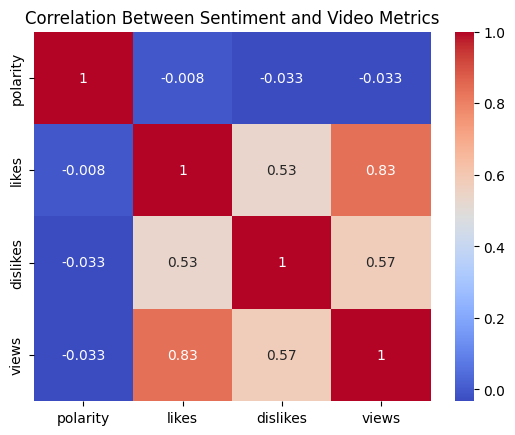

In [ ]:
# Merge video metrics with sentiment data
merged_data = train_comments.drop(columns='likes').merge(videos, on='video_id', how='right')

# Calculate correlation
correlation = merged_data[['polarity', 'likes', 'dislikes', 'views']].corr()
print(correlation)

# Visualize correlation
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between Sentiment and Video Metrics')
plt.show()

## Features and Target

In [ ]:
# Features and Target
X_train = train_merged_df['tokenized_text']
y_train = train_merged_df['sentiment_bin']

X_test = test_merged_df['tokenized_text']
y_test = test_merged_df['sentiment_bin']

Class imbalance is a common challenge in classification tasks, typically requiring manual correction through oversampling or undersampling. However, logistic regression offers a built-in solution to address this issue automatically, efficiently managing uneven class distributions without additional sampling steps.

## Model Training

### TF-IDF & Logistic Regression

In [ ]:
vectorizer = TfidfVectorizer() # Initialize the TF-IDF vectorizer
X_train_vect = vectorizer.fit_transform(X_train) # Fit and transform the training data
X_test_vect = vectorizer.transform(X_test)  # Transform the test data

In [ ]:
# Encode the target variable
label_encoder = LabelEncoder()  # Initialize the label encoder
y_train_encoded = label_encoder.fit_transform(y_train)  # Encode the training target variable
y_test_encoded = label_encoder.transform(y_test)  # Encode the test target variable

In [ ]:
log_model = LogisticRegression(class_weight='balanced',max_iter=200)  # Initialize the logistic regression model
log_model.fit(X_train_vect, y_train_encoded)  # Fit the model to the training data

# Make predictions on the test data
y_pred_encoded = log_model.predict(X_test_vect)  # Make predictions on the test data
y_pred = label_encoder.inverse_transform(y_pred_encoded)  # Decode the predictions back to the original labels

In [ ]:
report = classification_report(y_test, y_pred) # Generate the classification report
print(report) # Print the classification report

              precision    recall  f1-score   support

    negative       0.90      0.96      0.93     21500
     neutral       0.98      0.99      0.99     56645
    positive       0.99      0.96      0.97     60130

    accuracy                           0.97    138275
   macro avg       0.96      0.97      0.96    138275
weighted avg       0.97      0.97      0.97    138275

